# ML-100k vs Simulation — RMSE Comparison
5-fold CV RMSE on real ML-100k data vs synthetic simulation data across various parameter configurations.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

In [2]:
ROOT = Path.cwd().resolve()
for ROOT in [ROOT, *ROOT.parents]:
    if (ROOT / 'src').exists():
        break
else:
    raise RuntimeError('Could not find project root')
sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

Project root: C:\Users\mrari\OneDrive\Desktop\TFG\Sistemas de recomendación


In [3]:
from src.data.loading import load_movielens_100k
from src.utils.popularity import get_models
from src.features.affinity import affinity_matrix as build_affinity
from src.utils.cluster_simulation import generate_simulation

In [4]:
SURPRISE_MODELS = {('KNN' if k == 'CF User-Pearson' else k): v
                   for k, v in get_models().items() if k != 'Popularity'}
PALETTE = {m: c for m, c in zip(sorted(SURPRISE_MODELS), plt.cm.tab10.colors)}


def evaluate_rmse(ratings_long: pd.DataFrame, cv: int = 5) -> pd.DataFrame:
    """5-fold CV RMSE for each Surprise model. Returns DataFrame[Model, Fold, RMSE]."""
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(ratings_long[['UserID', 'MovieID', 'Rating']], reader)
    rows = []
    for name, algo in SURPRISE_MODELS.items():
        results = cross_validate(algo, data, measures=['RMSE'], cv=cv, verbose=False)
        for fold, rmse in enumerate(results['test_rmse']):
            rows.append({'Model': name, 'Fold': fold, 'RMSE': float(rmse)})
    return pd.DataFrame(rows)


def sim_to_long(R: np.ndarray) -> pd.DataFrame:
    """Convert U x I matrix (NaN = unrated) to long-format DataFrame."""
    df = pd.DataFrame(R).stack().reset_index()
    df.columns = ['UserID', 'MovieID', 'Rating']
    return df


def _run_simulation(config: dict) -> np.ndarray:
    """Build affinity matrix and run simulation, handling affinity_kind."""
    cfg = config.copy()
    kind = cfg.pop('affinity_kind', 'normal')
    A = build_affinity(
        n_user_clusters=cfg.get('n_user_clusters', 10),
        n_item_clusters=cfg.get('n_item_clusters', 10),
        kind=kind,
        seed=cfg.get('seed', 42),
    )
    return generate_simulation(**cfg, affinity=A)


def plot_sweep(sweep_df: pd.DataFrame, param: str, xlabel: str, title: str):
    """Line plot: x=param values, y=mean RMSE, one line per model, ±1 std shading."""
    agg = sweep_df.groupby([param, 'Model'])['RMSE'].agg(['mean', 'std']).reset_index()
    fig, ax = plt.subplots(figsize=(8, 5))
    for model in sorted(agg['Model'].unique()):
        sub = agg[agg['Model'] == model].sort_values(param)
        ax.plot(sub[param], sub['mean'], marker='o', label=model, color=PALETTE[model])
        ax.fill_between(sub[param],
                        sub['mean'] - sub['std'],
                        sub['mean'] + sub['std'],
                        alpha=0.15, color=PALETTE[model])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.legend(title='Model', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Helpers ready.')

Helpers ready.


In [5]:
DEFAULT = dict(
    U=1000, I=2000, density=0.06,
    alpha_user=0.9, alpha_item=0.9,
    seed=42,
    min_user_ratings=20, min_item_ratings=5,
    n_user_clusters=10, n_item_clusters=10,
    beta=1.0,
    tau=(-1.2, -0.4, 0.4, 1.2),
    mu=0.4, sigma_bu=0.5, sigma_bi=0.5, sigma_eps=0.4, gamma=0.4,
    affinity_kind='normal',
)

## ML-100k — 5-fold CV

In [6]:
ratings_df, _, _ = load_movielens_100k()
print(f'ML-100k: {len(ratings_df):,} ratings, {ratings_df["UserID"].nunique()} users, {ratings_df["MovieID"].nunique()} items')

print('Running 5-fold CV on ML-100k...')
ml_rmse_df = evaluate_rmse(ratings_df[['UserID', 'MovieID', 'Rating']])

ml_agg = ml_rmse_df.groupby('Model')['RMSE'].agg(['mean', 'std']).reset_index().sort_values('mean')
print(ml_agg.to_string(index=False))

ML-100k: 100,000 ratings, 943 users, 1682 items
Running 5-fold CV on ML-100k...
       Model     mean      std
       SVDpp 0.920130 0.004198
         SVD 0.935064 0.003085
BaselineOnly 0.943715 0.004850
         KNN 0.999838 0.007786
      Random 1.519545 0.005936


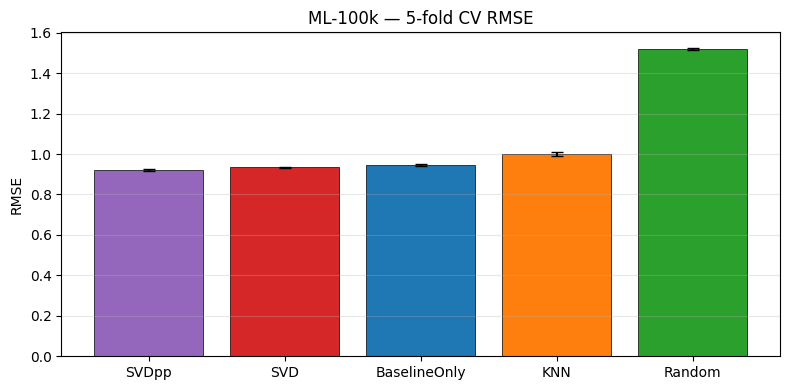

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
models_sorted = ml_agg['Model'].tolist()
means = ml_agg['mean'].tolist()
stds = ml_agg['std'].tolist()
colors = [PALETTE[m] for m in models_sorted]
bars = ax.bar(models_sorted, means, yerr=stds, capsize=4, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('RMSE')
ax.set_title('ML-100k — 5-fold CV RMSE')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Default simulation — 5-fold CV (10 seeds)

In [8]:
print('Running default simulation CV...')
sim_default_df = evaluate_rmse(sim_to_long(_run_simulation(DEFAULT)))

sim_default_agg = sim_default_df.groupby('Model')['RMSE'].agg(['mean', 'std']).reset_index().sort_values('mean')
print(sim_default_agg.to_string(index=False))

Running default simulation CV...
       Model     mean      std
       SVDpp 0.641777 0.003803
         SVD 0.661496 0.001724
BaselineOnly 0.690163 0.001067
         KNN 0.784353 0.003881
      Random 1.403995 0.004508


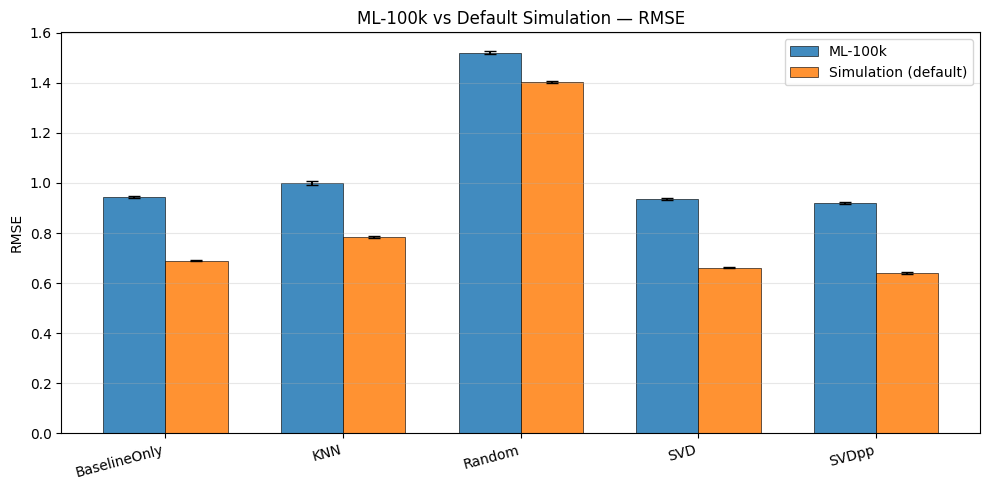

In [9]:
all_models = sorted(set(ml_agg['Model']) | set(sim_default_agg['Model']))
x = np.arange(len(all_models))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, agg) in enumerate([('ML-100k', ml_agg), ('Simulation (default)', sim_default_agg)]):
    agg_idx = agg.set_index('Model')
    means = [agg_idx.loc[m, 'mean'] if m in agg_idx.index else float('nan') for m in all_models]
    stds  = [agg_idx.loc[m, 'std']  if m in agg_idx.index else 0.0             for m in all_models]
    ax.bar(x + i * w, means, w, yerr=stds, capsize=4, label=label,
           edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xticks(x + w / 2)
ax.set_xticklabels(all_models, rotation=15, ha='right')
ax.set_ylabel('RMSE')
ax.set_title('ML-100k vs Default Simulation — RMSE')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Parameter sweeps

In [10]:
density_values = [0.01, 0.06, 0.1, 0.2]
density_rows = []
for val in density_values:
    print(f'density={val}')
    df = evaluate_rmse(sim_to_long(_run_simulation({**DEFAULT, 'density': val})))
    df['density'] = val
    density_rows.append(df)
density_df = pd.concat(density_rows, ignore_index=True)

density=0.01
density=0.06
density=0.1
density=0.2


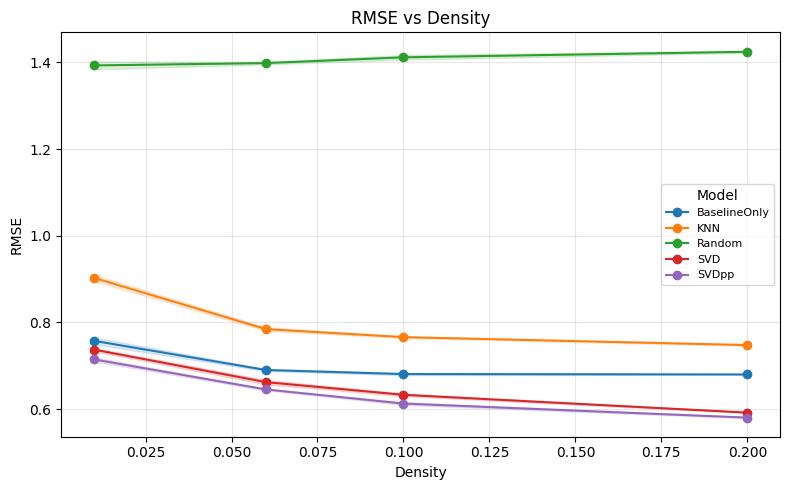

In [11]:
plot_sweep(density_df, 'density', 'Density', 'RMSE vs Density')

In [12]:
alphaitem_values = [0, 0.45, 0.9, 1.3]
alphaitem_rows = []
for val in alphaitem_values:
    print(f'alpha_item={val}')
    df = evaluate_rmse(sim_to_long(_run_simulation({**DEFAULT, 'alpha_item': val})))
    df['alpha_item'] = val
    alphaitem_rows.append(df)
alphaitem_df = pd.concat(alphaitem_rows, ignore_index=True)

alpha_item=0
alpha_item=0.45
alpha_item=0.9
alpha_item=1.3


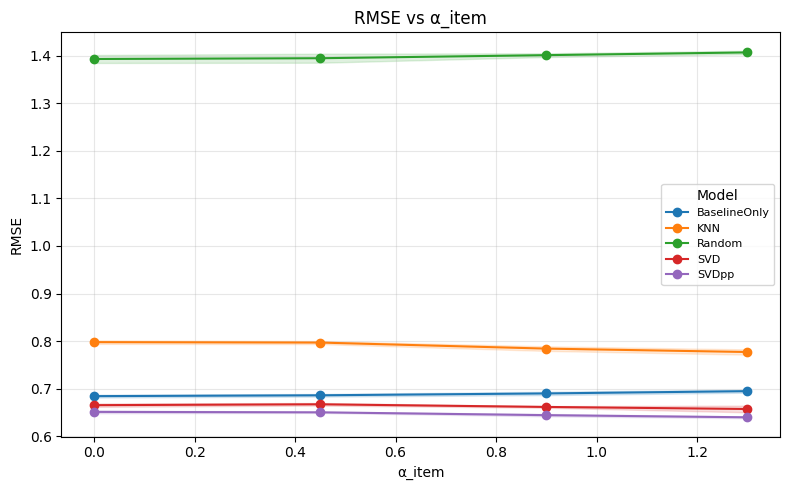

In [13]:
plot_sweep(alphaitem_df, 'alpha_item', 'α_item', 'RMSE vs α_item')

In [14]:
alphauser_values = [0, 0.45, 0.9, 1.3]
alphauser_rows = []
for val in alphauser_values:
    print(f'alpha_user={val}')
    df = evaluate_rmse(sim_to_long(_run_simulation({**DEFAULT, 'alpha_user': val})))
    df['alpha_user'] = val
    alphauser_rows.append(df)
alphauser_df = pd.concat(alphauser_rows, ignore_index=True)

alpha_user=0
alpha_user=0.45
alpha_user=0.9
alpha_user=1.3


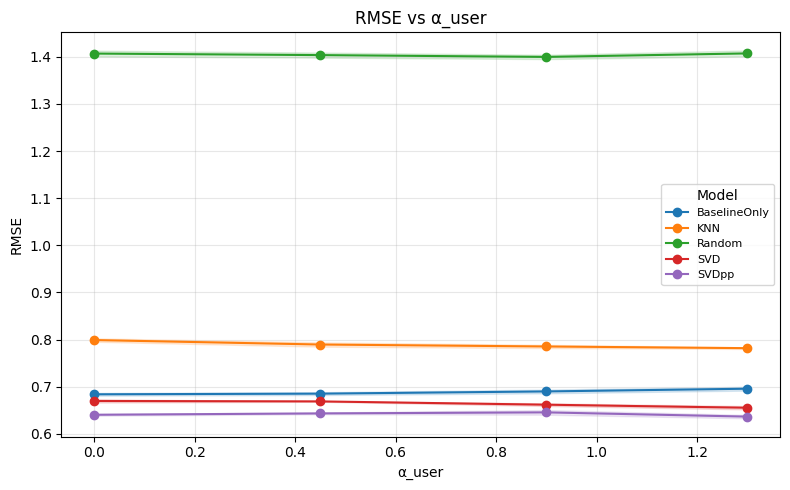

In [15]:
plot_sweep(alphauser_df, 'alpha_user', 'α_user', 'RMSE vs α_user')

In [16]:
from scipy.stats import norm
from surprise.model_selection import KFold

sigmaeps_values = [0, 0.4, 0.8, 1.2]
sigmaeps_rows = []
sigmaeps_dist_params = []

for val in sigmaeps_values:
    print(f'sigma_eps={val}')
    R = _run_simulation({**DEFAULT, 'sigma_eps': val})
    ratings_long = sim_to_long(R)

    df = evaluate_rmse(ratings_long)
    df['sigma_eps'] = val
    sigmaeps_rows.append(df)

    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(ratings_long[['UserID', 'MovieID', 'Rating']], reader)
    fold_mus, fold_sigmas = [], []
    for trainset, _ in KFold(n_splits=5).split(data):
        r = np.array([r for (_, _, r) in trainset.all_ratings()])
        fold_mus.append(r.mean())
        fold_sigmas.append(r.std())
    sigmaeps_dist_params.append((val, np.mean(fold_mus), np.mean(fold_sigmas)))

sigmaeps_df = pd.concat(sigmaeps_rows, ignore_index=True)

sigma_eps=0
sigma_eps=0.4
sigma_eps=0.8
sigma_eps=1.2


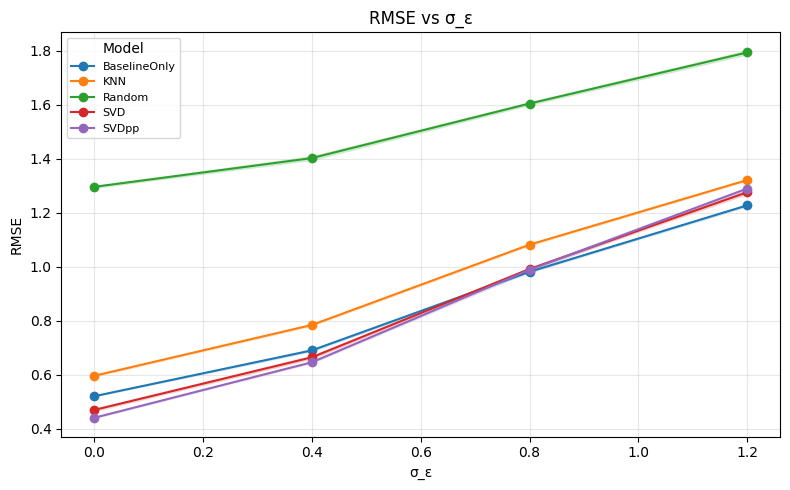

In [17]:
plot_sweep(sigmaeps_df, 'sigma_eps', 'σ_ε', 'RMSE vs σ_ε')

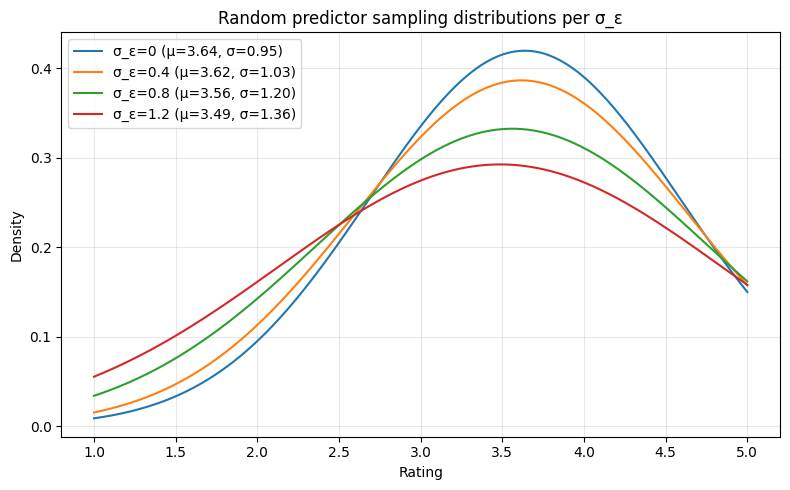

In [18]:
x = np.linspace(1, 5, 300)
fig, ax = plt.subplots(figsize=(8, 5))
for val, mu, sigma in sigmaeps_dist_params:
    ax.plot(x, norm.pdf(x, mu, sigma), label=f'σ_ε={val} (μ={mu:.2f}, σ={sigma:.2f})')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_title('Random predictor sampling distributions per σ_ε')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
gamma_values = [0, 0.5, 1, 1.5, 2]
gamma_rows = []
for val in gamma_values:
    print(f'gamma={val}')
    df = evaluate_rmse(sim_to_long(_run_simulation({**DEFAULT, 'gamma': val})))
    df['gamma'] = val
    gamma_rows.append(df)
gamma_df = pd.concat(gamma_rows, ignore_index=True)

gamma=0
gamma=0.5
gamma=1
gamma=1.5
gamma=2


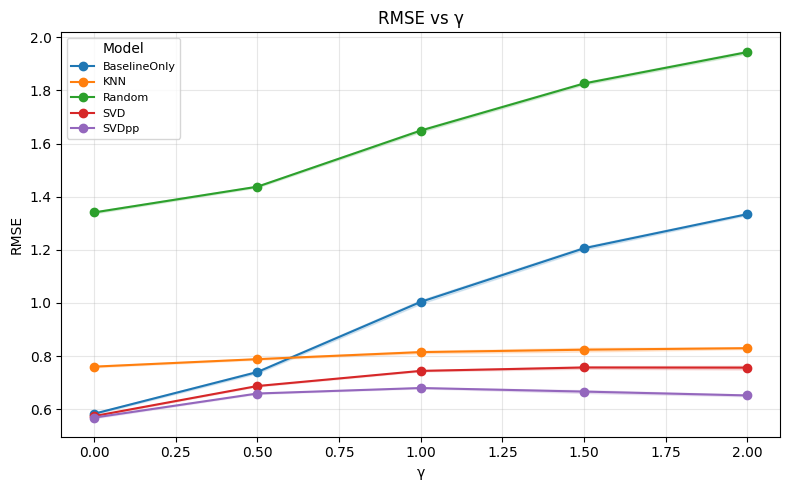

In [7]:
plot_sweep(gamma_df, 'gamma', 'γ', 'RMSE vs γ')

In [8]:
sigmbu_values = [0, 0.4, 0.8, 1.2]
sigmbu_rows = []
for val in sigmbu_values:
    print(f'sigma_bu={val}')
    df = evaluate_rmse(sim_to_long(_run_simulation({**DEFAULT, 'sigma_bu': val})))
    df['sigma_bu'] = val
    sigmbu_rows.append(df)
sigmbu_df = pd.concat(sigmbu_rows, ignore_index=True)

sigma_bu=0
sigma_bu=0.4
sigma_bu=0.8
sigma_bu=1.2


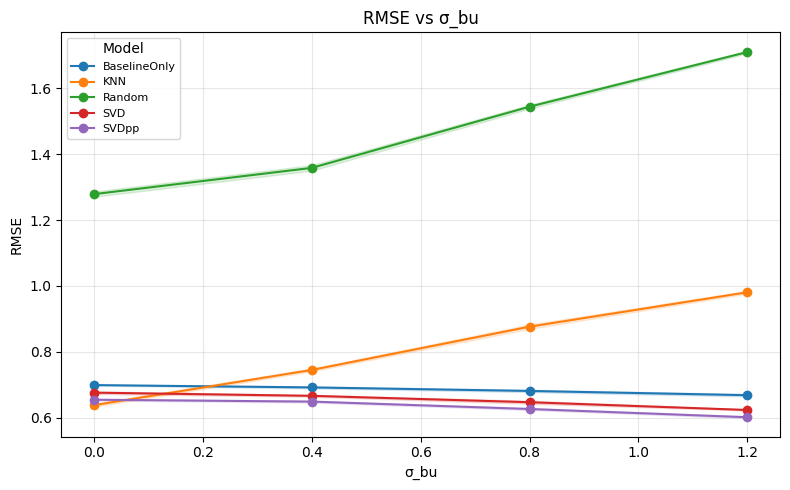

In [9]:
plot_sweep(sigmbu_df, 'sigma_bu', 'σ_bu', 'RMSE vs σ_bu')

In [10]:
sigmbi_values = [0, 0.4, 0.8, 1.2]
sigmbi_rows = []
for val in sigmbi_values:
    print(f'sigma_bi={val}')
    df = evaluate_rmse(sim_to_long(_run_simulation({**DEFAULT, 'sigma_bi': val})))
    df['sigma_bi'] = val
    sigmbi_rows.append(df)
sigmbi_df = pd.concat(sigmbi_rows, ignore_index=True)

sigma_bi=0
sigma_bi=0.4
sigma_bi=0.8
sigma_bi=1.2


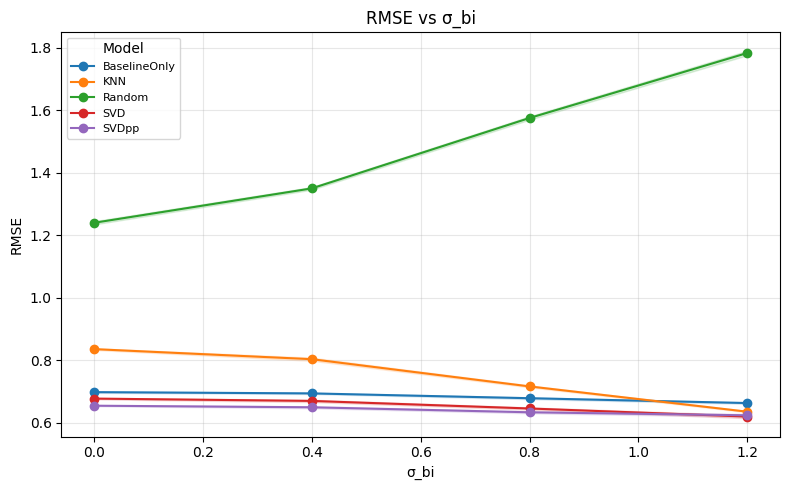

In [11]:
plot_sweep(sigmbi_df, 'sigma_bi', 'σ_bi', 'RMSE vs σ_bi')